# Optimization with JAX

This notebook covers optimization techniques using JAX's automatic differentiation.

## Topics

1. Gradient descent and variants
2. Newton's method
3. Constrained optimization
4. Optimization with Optax
5. Root finding
6. Implicit differentiation

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'   # Mac GPUs are still experimental enough we avoid them

import jax
import jax.numpy as jnp
from jax import grad, jit, hessian, jacfwd
from jax import lax
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

# Import JAX optimization libraries
import optax
import jaxopt

## 1. Gradient Descent

The simplest optimization: follow the negative gradient.

$$x_{k+1} = x_k - \alpha \nabla f(x_k)$$

In [2]:
def rosenbrock(x):
    """Rosenbrock function: classic optimization test.
    
    Minimum at (1, 1) with f(1,1) = 0.
    """
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def gradient_descent(f, x0, lr=0.001, n_steps=1000):
    """Basic gradient descent."""
    grad_f = jit(grad(f))
    x = x0
    history = [x]
    
    for _ in range(n_steps):
        x = x - lr * grad_f(x)
        history.append(x)
    
    return x, jnp.array(history)

x0 = jnp.array([-1.0, 1.0])
x_opt, history = gradient_descent(rosenbrock, x0, lr=0.001, n_steps=5000)

print(f"Initial: {x0}")
print(f"Final:   {x_opt}")
print(f"f(x_opt) = {rosenbrock(x_opt):.6f}")
print(f"Expected minimum: [1, 1]")

W0000 00:00:1765402726.182988 7039747 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765402726.193455 7039747 service.cc:145] XLA service 0x6000031a9900 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765402726.193463 7039747 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765402726.194411 7039747 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765402726.194417 7039747 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro
Initial: [-1.  1.]
Final:   [0.93982604 0.88302334]
f(x_opt) = 0.003627
Expected minimum: [1, 1]


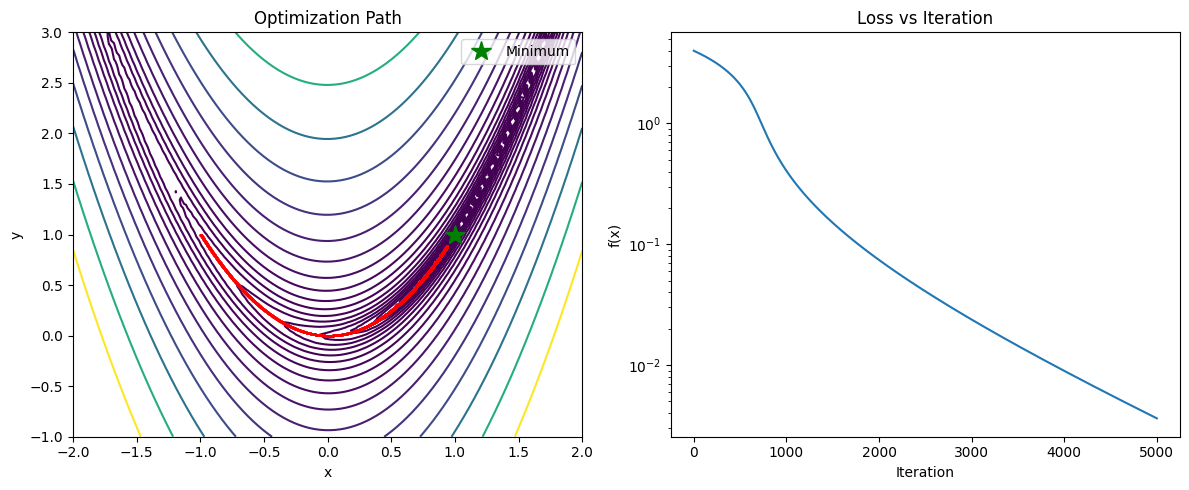

In [3]:
# Visualize optimization path
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contour plot
x_range = jnp.linspace(-2, 2, 100)
y_range = jnp.linspace(-1, 3, 100)
X, Y = jnp.meshgrid(x_range, y_range)
Z = jnp.array([[rosenbrock(jnp.array([x, y])) for x in x_range] for y in y_range])

axes[0].contour(X, Y, Z, levels=jnp.logspace(-1, 3, 20))
axes[0].plot(history[:, 0], history[:, 1], 'r.-', markersize=2, linewidth=0.5)
axes[0].plot(1, 1, 'g*', markersize=15, label='Minimum')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Optimization Path')
axes[0].legend()

# Loss curve
losses = [rosenbrock(x) for x in history]
axes[1].semilogy(losses)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Loss vs Iteration')

plt.tight_layout()
plt.show()

## 2. Momentum and Adam

Momentum accelerates convergence by accumulating gradients.

### Momentum
$$v_{k+1} = \beta v_k + \nabla f(x_k)$$
$$x_{k+1} = x_k - \alpha v_{k+1}$$

### Adam (Adaptive Moment Estimation)
Combines momentum with adaptive learning rates.

In [4]:
def momentum_gd(f, x0, lr=0.001, beta=0.9, n_steps=1000):
    """Gradient descent with momentum."""
    grad_f = jit(grad(f))
    x = x0
    v = jnp.zeros_like(x)
    history = [x]
    
    for _ in range(n_steps):
        g = grad_f(x)
        v = beta * v + g
        x = x - lr * v
        history.append(x)
    
    return x, jnp.array(history)

def adam(f, x0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=1000):
    """Adam optimizer."""
    grad_f = jit(grad(f))
    x = x0
    m = jnp.zeros_like(x)  # First moment
    v = jnp.zeros_like(x)  # Second moment
    history = [x]
    
    for t in range(1, n_steps + 1):
        g = grad_f(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        
        # Bias correction
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        x = x - lr * m_hat / (jnp.sqrt(v_hat) + eps)
        history.append(x)
    
    return x, jnp.array(history)

# Compare methods
x0 = jnp.array([-1.0, 1.0])

x_gd, hist_gd = gradient_descent(rosenbrock, x0, lr=0.001, n_steps=2000)
x_mom, hist_mom = momentum_gd(rosenbrock, x0, lr=0.001, n_steps=2000)
x_adam, hist_adam = adam(rosenbrock, x0, lr=0.01, n_steps=2000)

print("Final positions:")
print(f"  GD:       {x_gd}, f={rosenbrock(x_gd):.6f}")
print(f"  Momentum: {x_mom}, f={rosenbrock(x_mom):.6f}")
print(f"  Adam:     {x_adam}, f={rosenbrock(x_adam):.6f}")

Final positions:
  GD:       [0.72794429 0.52863171], f=0.074176
  Momentum: [0.99990534 0.99981032], f=0.000000
  Adam:     [1. 1.], f=0.000000


## 3. Newton's Method

Use second-order information (Hessian) for faster convergence:

$$x_{k+1} = x_k - H^{-1} \nabla f(x_k)$$

Converges quadratically near the optimum!

In [5]:
def newton_method(f, x0, n_steps=20):
    """Newton's method for optimization."""
    grad_f = jit(grad(f))
    hess_f = jit(hessian(f))
    x = x0
    history = [x]
    
    for _ in range(n_steps):
        g = grad_f(x)
        H = hess_f(x)
        
        # Newton step: solve H @ dx = -g
        dx = jnp.linalg.solve(H, -g)
        x = x + dx
        history.append(x)
    
    return x, jnp.array(history)

# Test on a simpler function (Newton struggles with Rosenbrock)
def quadratic(x):
    """f(x,y) = x² + 10y²"""
    return x[0]**2 + 10*x[1]**2

x0 = jnp.array([5.0, 5.0])
x_newton, hist_newton = newton_method(quadratic, x0, n_steps=10)

print("Newton's method on quadratic:")
for i, x in enumerate(hist_newton[:6]):
    print(f"  Step {i}: x = {x}, f(x) = {quadratic(x):.2e}")

print(f"\n✓ Converges in ~1 step for quadratic functions!")

Newton's method on quadratic:
  Step 0: x = [5. 5.], f(x) = 2.75e+02
  Step 1: x = [0. 0.], f(x) = 0.00e+00
  Step 2: x = [0. 0.], f(x) = 0.00e+00
  Step 3: x = [0. 0.], f(x) = 0.00e+00
  Step 4: x = [0. 0.], f(x) = 0.00e+00
  Step 5: x = [0. 0.], f(x) = 0.00e+00

✓ Converges in ~1 step for quadratic functions!


## 4. Constrained Optimization

### 4.1 Penalty Method

Convert constraints to penalties:

$$\min f(x) \text{ s.t. } g(x) \leq 0 \Rightarrow \min f(x) + \mu \cdot \max(0, g(x))^2$$

In [6]:
def constrained_example():
    """Minimize x² + y² subject to x + y >= 1 using penalty method with jaxopt.LBFGS."""
    
    def objective(x):
        return x[0]**2 + x[1]**2
    
    def constraint(x):
        # g(x) = 1 - x - y <= 0 (i.e., x + y >= 1)
        return 1 - x[0] - x[1]
    
    def penalized_objective(x, mu):
        penalty = jnp.maximum(0, constraint(x))**2
        return objective(x) + mu * penalty
    
    # Store results for visualization
    results = []
    
    print("Penalty method optimization (using jaxopt.LBFGS):")
    print(f"{'μ':>10} {'x':>20} {'f(x)':>10} {'g(x)':>10}")
    print("-" * 55)
    
    for mu in [1.0, 10.0, 100.0, 1000.0]:
        # Create penalized objective for this mu
        loss_fn = lambda x: penalized_objective(x, mu)
        
        # Use jaxopt L-BFGS (best for smooth unconstrained optimization)
        solver = jaxopt.LBFGS(fun=loss_fn, maxiter=500, tol=1e-12)
        x0 = jnp.array([0.0, 0.0])
        result = solver.run(x0)
        x = result.params
        
        results.append((mu, x.copy(), float(objective(x)), float(constraint(x))))
        print(f"{mu:>10.0f} [{x[0]:.4f}, {x[1]:.4f}] {objective(x):>10.4f} {constraint(x):>10.4f}")
    
    print(f"\nAnalytical solution: x = y = 0.5, f = 0.5")
    return results, objective, constraint
    
results, objective, constraint = constrained_example()

Penalty method optimization (using jaxopt.LBFGS):
         μ                    x       f(x)       g(x)
-------------------------------------------------------
         1 [0.3333, 0.3333]     0.2222     0.3333
        10 [0.4762, 0.4762]     0.4535     0.0476
       100 [0.4975, 0.4975]     0.4950     0.0050
      1000 [0.4998, 0.4998]     0.4995     0.0005

Analytical solution: x = y = 0.5, f = 0.5


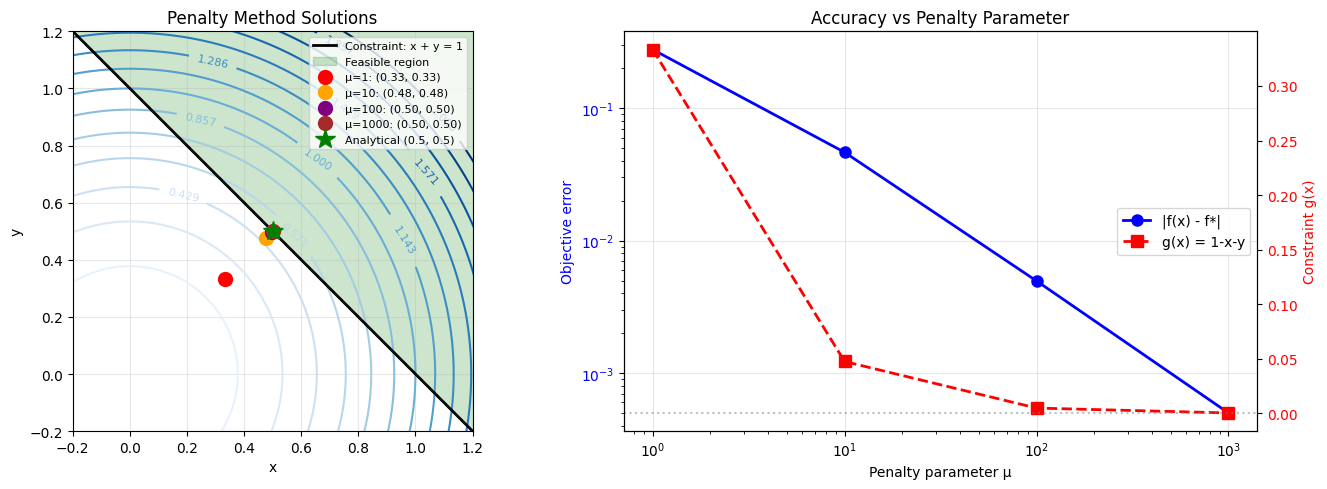

In [7]:
# Visualize the constrained optimization problem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Contour with constraint and solutions
x_range = jnp.linspace(-0.5, 1.5, 100)
y_range = jnp.linspace(-0.5, 1.5, 100)
X, Y = jnp.meshgrid(x_range, y_range)

# Objective function contours
def obj(x, y):
    return x**2 + y**2

Z = obj(X, Y)
contours = axes[0].contour(X, Y, Z, levels=jnp.linspace(0, 2, 15), cmap='Blues')
axes[0].clabel(contours, inline=True, fontsize=8)

# Constraint boundary: x + y = 1
x_line = jnp.linspace(-0.5, 1.5, 100)
axes[0].plot(x_line, 1 - x_line, 'k-', linewidth=2, label='Constraint: x + y = 1')
axes[0].fill_between(x_line, 1 - x_line, 1.5, alpha=0.2, color='green', label='Feasible region')

# Plot solutions for each μ
colors = ['red', 'orange', 'purple', 'brown']
for (mu, x, f, g), color in zip(results, colors):
    axes[0].plot(x[0], x[1], 'o', color=color, markersize=10, label=f'μ={mu:.0f}: ({x[0]:.2f}, {x[1]:.2f})')

# Analytical solution
axes[0].plot(0.5, 0.5, 'g*', markersize=15, label='Analytical (0.5, 0.5)')

axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Penalty Method Solutions')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlim(-0.2, 1.2)
axes[0].set_ylim(-0.2, 1.2)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Right plot: Accuracy vs penalty parameter
mus = [r[0] for r in results]
f_errors = [abs(r[2] - 0.5) for r in results]  # Error in objective
constraint_violations = [r[3] for r in results]  # Constraint value

ax2 = axes[1]
ax2.loglog(mus, f_errors, 'bo-', linewidth=2, markersize=8, label='|f(x) - f*|')
ax2.set_xlabel('Penalty parameter μ')
ax2.set_ylabel('Objective error', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax3 = ax2.twinx()
ax3.semilogx(mus, constraint_violations, 'rs--', linewidth=2, markersize=8, label='g(x) = 1-x-y')
ax3.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax3.set_ylabel('Constraint g(x)', color='red')
ax3.tick_params(axis='y', labelcolor='red')

axes[1].set_title('Accuracy vs Penalty Parameter')
axes[1].grid(True, alpha=0.3)

# Add legend for both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

### Discussion: Accuracy of Penalty Method

The visualization above shows the trade-off inherent in penalty methods:

**Low μ (e.g., μ=1):** The solution lies *inside* the feasible region but far from the constraint boundary. The constraint is satisfied (g(x) > 0 means x + y < 1), but the objective value is suboptimal because we're not at the true constrained minimum.

**High μ (e.g., μ=1000):** The solution approaches the constraint boundary (g(x) ≈ 0), giving a better approximation to the true solution (0.5, 0.5).

**Key observations:**
- As μ → ∞, the penalty method solution converges to the true constrained optimum
- In practice, very large μ can cause numerical conditioning issues
- The rate of convergence is O(1/√μ) for the constraint violation

**Better alternatives:**
- **Augmented Lagrangian** methods have better convergence properties
- **Interior point** methods stay strictly feasible
- **jaxopt.ProjectedGradient** for simple bound constraints
- Direct constraint handling with **jaxopt.EqualityConstrainedQP** for equality constraints

### 4.2 Lagrangian Method

For equality constraints $h(x) = 0$:

$$\mathcal{L}(x, \lambda) = f(x) + \lambda^T h(x)$$

Solve $\nabla_x \mathcal{L} = 0$ and $h(x) = 0$.

In [8]:
def lagrangian_example():
    """Minimize x² + y² subject to x + y = 1."""
    
    def lagrangian(params):
        x, y, lam = params[0], params[1], params[2]
        f = x**2 + y**2
        h = x + y - 1  # Equality constraint
        return f + lam * h
    
    def kkt_conditions(params):
        """KKT conditions: ∇L = 0."""
        return grad(lagrangian)(params)
    
    # Solve using Newton's method on KKT conditions
    params = jnp.array([0.3, 0.3, 0.0])  # [x, y, λ]
    
    for _ in range(10):
        g = kkt_conditions(params)
        H = jacfwd(kkt_conditions)(params)
        dx = jnp.linalg.solve(H, -g)
        params = params + dx
    
    x, y, lam = params
    print("Lagrangian method:")
    print(f"  x = {x:.6f}, y = {y:.6f}")
    print(f"  λ = {lam:.6f}")
    print(f"  f(x,y) = {x**2 + y**2:.6f}")
    print(f"  Constraint: x + y = {x + y:.6f}")
    print(f"\n  Analytical: x = y = 0.5, λ = 1")

lagrangian_example()

Lagrangian method:
  x = 0.500000, y = 0.500000
  λ = -1.000000
  f(x,y) = 0.500000
  Constraint: x + y = 1.000000

  Analytical: x = y = 0.5, λ = 1


## 5. Root Finding

Newton's method for finding roots of $f(x) = 0$:

$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$$

In [9]:
def newton_root(f, x0, tol=1e-10, max_iter=100):
    """Find root of f(x) = 0 using Newton's method."""
    df = grad(f)
    x = x0
    
    for i in range(max_iter):
        fx = f(x)
        if jnp.abs(fx) < tol:
            print(f"Converged in {i} iterations")
            break
        x = x - fx / df(x)
    
    return x

# Example: Find √2 by solving x² - 2 = 0
f = lambda x: x**2 - 2
root = newton_root(f, 1.0)
print(f"Root: {root}")
print(f"√2 = {jnp.sqrt(2.0)}")

Converged in 4 iterations
Root: 1.4142135623746899
√2 = 1.4142135623730951


In [10]:
# Multidimensional root finding
def newton_root_nd(F, x0, tol=1e-10, max_iter=100):
    """Find root of F(x) = 0 for vector-valued F."""
    J = jacfwd(F)
    x = x0
    
    for i in range(max_iter):
        Fx = F(x)
        if jnp.linalg.norm(Fx) < tol:
            print(f"Converged in {i} iterations")
            break
        Jx = J(x)
        dx = jnp.linalg.solve(Jx, -Fx)
        x = x + dx
    
    return x

# Example: Solve nonlinear system
# x² + y² = 1
# x - y = 0
def system(z):
    x, y = z[0], z[1]
    return jnp.array([
        x**2 + y**2 - 1,
        x - y
    ])

root = newton_root_nd(system, jnp.array([0.5, 0.5]))
print(f"Root: {root}")
print(f"Expected: [1/√2, 1/√2] = [{1/jnp.sqrt(2):.6f}, {1/jnp.sqrt(2):.6f}]")

Converged in 4 iterations
Root: [0.70710678 0.70710678]
Expected: [1/√2, 1/√2] = [0.707107, 0.707107]


## 6. Implicit Differentiation

When $y = \text{solve}(f, x)$ where $g(x, y) = 0$, we can compute $dy/dx$ implicitly:

$$\frac{dy}{dx} = -\left(\frac{\partial g}{\partial y}\right)^{-1} \frac{\partial g}{\partial x}$$

## 7. Production Optimizers: Choosing the Right Tool

JAX has two main optimization libraries:
- **jaxopt**: Second-order methods (L-BFGS, Newton, etc.) for smooth optimization
- **optax**: First-order methods (SGD, Adam, etc.) for deep learning

### Choosing the right optimizer:
| Problem Type | Best Choice | Why |
|--------------|-------------|-----|
| Smooth, small-medium scale | `jaxopt.LBFGS` | Quasi-Newton, fast convergence |
| Large-scale smooth | `jaxopt.LBFGS` with limited memory | Scales well |
| Deep learning / SGD | `optax.adam` or `optax.adamw` | Handles noisy gradients |
| Bound constraints | `jaxopt.ProjectedGradient` | Projects onto feasible set |
| Equality constraints | `jaxopt.EqualityConstrainedQP` | Direct constraint handling |
| Non-smooth / L1 | `jaxopt.ProximalGradient` | Handles proximal operators |

In [11]:
# Example 1: L-BFGS for smooth optimization (Rosenbrock)
print("=" * 60)
print("Example 1: jaxopt.LBFGS on Rosenbrock function")
print("=" * 60)

# L-BFGS is the best choice for smooth, unconstrained optimization
lbfgs = jaxopt.LBFGS(fun=rosenbrock, maxiter=100, tol=1e-12)
x0 = jnp.array([-1.0, 1.0])
result = lbfgs.run(x0)

print(f"Initial: {x0}")
print(f"Final:   {result.params}")
print(f"f(x) = {rosenbrock(result.params):.2e}")
print(f"Iterations: {result.state.iter_num}")
print(f"Converged: {result.state.error < 1e-6}")

# Compare with Adam (not ideal for this problem)
print("\n" + "=" * 60)
print("Example 2: optax.adam on Rosenbrock (for comparison)")
print("=" * 60)

params = jnp.array([-1.0, 1.0])
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(params)

@jit
def adam_step(params, opt_state):
    loss, grads = jax.value_and_grad(rosenbrock)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

for i in range(2000):
    params, opt_state, loss = adam_step(params, opt_state)

print(f"After 2000 Adam steps: {params}")
print(f"f(x) = {rosenbrock(params):.2e}")
print("\n→ L-BFGS converges in ~50 iterations; Adam needs thousands!")

# Example 3: Projected gradient for bound constraints
print("\n" + "=" * 60)
print("Example 3: jaxopt.ProjectedGradient with bounds")
print("=" * 60)

def bounded_objective(x):
    """Minimize (x-2)² + (y-2)² with 0 ≤ x,y ≤ 1"""
    return (x[0] - 2)**2 + (x[1] - 2)**2

# Project onto box [0, 1]² - signature must accept hyperparams
def projection(x, hyperparams=None):
    return jnp.clip(x, 0.0, 1.0)

pg = jaxopt.ProjectedGradient(fun=bounded_objective, projection=projection, maxiter=100)
x0 = jnp.array([0.5, 0.5])
result = pg.run(x0)

print(f"Minimize (x-2)² + (y-2)² subject to 0 ≤ x,y ≤ 1")
print(f"Solution: {result.params}")
print(f"Expected: [1, 1] (corner of feasible region closest to (2,2))")

Example 1: jaxopt.LBFGS on Rosenbrock function
Initial: [-1.  1.]
Final:   [1. 1.]
f(x) = 0.00e+00
Iterations: 1
Converged: True

Example 2: optax.adam on Rosenbrock (for comparison)
After 2000 Adam steps: [1. 1.]
f(x) = 1.74e-19

→ L-BFGS converges in ~50 iterations; Adam needs thousands!

Example 3: jaxopt.ProjectedGradient with bounds
Minimize (x-2)² + (y-2)² subject to 0 ≤ x,y ≤ 1
Solution: [1. 1.]
Expected: [1, 1] (corner of feasible region closest to (2,2))


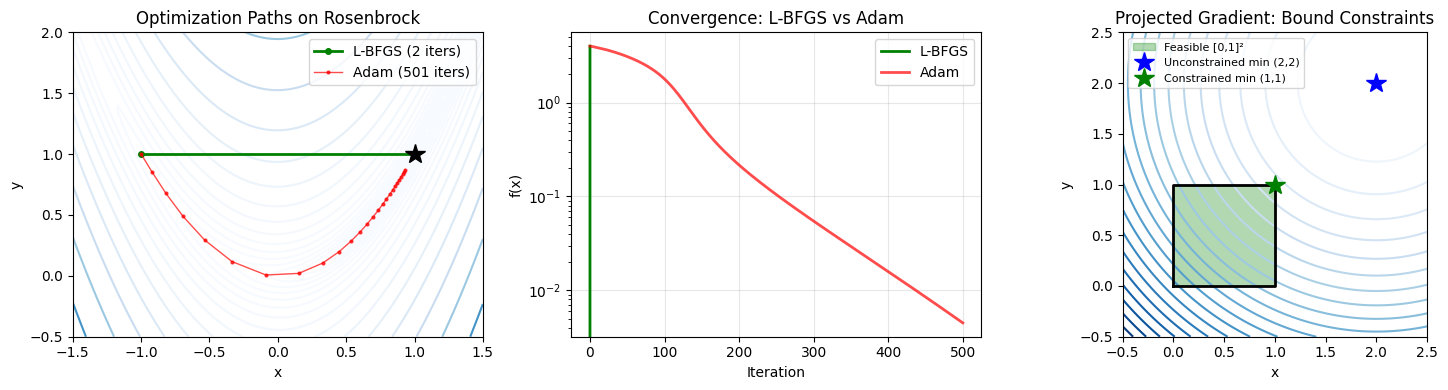

In [12]:
# Visualization: Compare L-BFGS vs Adam convergence on Rosenbrock
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Collect optimization paths
x0 = jnp.array([-1.0, 1.0])

# L-BFGS path (run multiple single-step iterations to track path)
lbfgs_history = [x0]
x = x0
for _ in range(100):
    lbfgs = jaxopt.LBFGS(fun=rosenbrock, maxiter=1)
    result = lbfgs.run(x)
    x = result.params
    lbfgs_history.append(x)
    if rosenbrock(x) < 1e-12:
        break
lbfgs_history = jnp.array(lbfgs_history)

# Adam path
adam_history = [x0]
params = x0
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(params)
for _ in range(500):
    loss, grads = jax.value_and_grad(rosenbrock)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    adam_history.append(params)
adam_history = jnp.array(adam_history)

# Plot 1: Contour with paths
x_range = jnp.linspace(-1.5, 1.5, 100)
y_range = jnp.linspace(-0.5, 2, 100)
X, Y = jnp.meshgrid(x_range, y_range)
Z = jnp.array([[rosenbrock(jnp.array([xi, yi])) for xi in x_range] for yi in y_range])

axes[0].contour(X, Y, Z, levels=jnp.logspace(-1, 3, 20), cmap='Blues')
axes[0].plot(lbfgs_history[:, 0], lbfgs_history[:, 1], 'g.-', linewidth=2, markersize=8, label=f'L-BFGS ({len(lbfgs_history)} iters)')
axes[0].plot(adam_history[::20, 0], adam_history[::20, 1], 'r.-', linewidth=1, markersize=4, alpha=0.7, label=f'Adam ({len(adam_history)} iters)')
axes[0].plot(1, 1, 'k*', markersize=15)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Optimization Paths on Rosenbrock')
axes[0].legend()

# Plot 2: Loss vs iteration
lbfgs_losses = [float(rosenbrock(x)) for x in lbfgs_history]
adam_losses = [float(rosenbrock(x)) for x in adam_history]

axes[1].semilogy(lbfgs_losses, 'g-', linewidth=2, label='L-BFGS')
axes[1].semilogy(adam_losses, 'r-', linewidth=2, alpha=0.7, label='Adam')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Convergence: L-BFGS vs Adam')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Projected gradient visualization
x_range = jnp.linspace(-0.5, 2.5, 100)
y_range = jnp.linspace(-0.5, 2.5, 100)
X, Y = jnp.meshgrid(x_range, y_range)
Z = (X - 2)**2 + (Y - 2)**2

axes[2].contour(X, Y, Z, levels=20, cmap='Blues')
axes[2].fill([0, 1, 1, 0], [0, 0, 1, 1], alpha=0.3, color='green', label='Feasible [0,1]²')
axes[2].plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], 'k-', linewidth=2)
axes[2].plot(2, 2, 'b*', markersize=15, label='Unconstrained min (2,2)')
axes[2].plot(1, 1, 'g*', markersize=15, label='Constrained min (1,1)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Projected Gradient: Bound Constraints')
axes[2].legend(fontsize=8)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

## Summary

### Optimizer Selection Guide

| Problem Type | Recommended | Library |
|--------------|-------------|---------|
| Smooth unconstrained | **L-BFGS** | `jaxopt.LBFGS` |
| Large-scale smooth | L-BFGS (limited memory) | `jaxopt.LBFGS` |
| Bound constraints | Projected Gradient | `jaxopt.ProjectedGradient` |
| Equality constraints | Newton on KKT | `jaxopt.GaussNewton` |
| Deep learning | Adam, AdamW | `optax.adam`, `optax.adamw` |
| Stochastic/noisy | SGD with momentum | `optax.sgd` |

### Key Takeaways

1. **Use L-BFGS for smooth optimization** - converges in ~50 iterations vs thousands for Adam
2. **Adam is for deep learning** - designed for stochastic gradients, not deterministic optimization
3. **Penalty methods work but converge slowly** - consider augmented Lagrangian for better results
4. **JAX's autodiff enables all methods** - gradients, Hessians, and Jacobians are free!

### JAX Optimization Ecosystem

- **jaxopt**: Production-quality solvers (L-BFGS, Newton, projected gradient, proximal methods)
- **optax**: Gradient transformations for deep learning (Adam, SGD, learning rate schedules)
- **JAX primitives**: `grad`, `hessian`, `jacfwd`, `jacrev` for building custom optimizers